# Análisis Exploratorio de Datos (EDA)

**Dataset:** Million Song Dataset + Spotify + Last.fm

**Objetivo del notebook:** explorar el dataset de historial de escuchas musicales y preparar los datos para los modelos de filtrado colaborativo que se compararán en el trabajo.

**Salida esperada al final:** un único `DataFrame` filtrado y dividido en train/test, listo para ser consumido por todos los modelos (baseline, KNN, PMF, GMF, MLP).

**Decisiones que tomamos a lo largo del EDA:**
1. Aplicar **k-core filtering** (`k_user = 5`, `k_item = 10`) para descartar usuarios y canciones con muy pocas interacciones.
2. Transformar `playcount` a un **rating sintético en escala continua [1, 5]** mediante `log1p` + clipping al percentil 99 + escalado min-max. Esto permite usar pérdida MSE manteniendo coherencia con el notebook de NCF visto en clase.
3. Aplicar un **split estratificado por usuario (80/20)** para garantizar que todo usuario aparece tanto en train como en test.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import pickle


SEED = 42
np.random.seed(SEED)

## 1. Carga de los datasets

Disponemos de dos archivos:
- **`Music Info.csv`**: metadatos descriptivos de cada canción (artista, género, features de Spotify...). Solo lo usaremos puntualmente como contexto; **no entra en los modelos de filtrado colaborativo**.
- **`User Listening History.csv`**: historial de escuchas con tuplas `(user_id, track_id, playcount)`. Este es **el dataset principal** del trabajo.

Para la carga del historial usamos `dtype='category'` en los IDs y `uint16` en `playcount` para reducir drásticamente el consumo de memoria (sin estas optimizaciones el CSV de 9.7 M filas no entra cómodamente en RAM).

In [2]:
# 1.1) Metadatos de las canciones
df_music = pd.read_csv('../data/raw/Music Info.csv')

# 1.2) Historial de escuchas (carga optimizada)
dtype_dict = {
    'track_id': 'category',
    'user_id': 'category',
    'playcount': 'uint16'
}
df_history = pd.read_csv('../data/raw/User Listening History.csv', dtype=dtype_dict)

df_history.head(3)

,track_id,user_id,playcount
0,TRIRLYL128F42539D1,b80344d063b5ccb3212f76538f3d9e43d87dca9e,1
1,TRFUPBA128F934F7E1,b80344d063b5ccb3212f76538f3d9e43d87dca9e,1
2,TRLQPQJ128F42AA94F,b80344d063b5ccb3212f76538f3d9e43d87dca9e,1


### 1.1. Tamaños y nulos

Antes de profundizar, comprobamos higiene básica de ambos datasets: dimensiones y presencia de valores nulos.

In [3]:
print(f"Music Info: {df_music.shape}")
print(f"Nulos por columna en Music Info:\n{df_music.isnull().sum()}\n")

print(f"Listening History: {df_history.shape}")
print(f"Nulos por columna en Listening History:\n{df_history.isnull().sum()}")

Music Info: (50683, 21)
Nulos por columna en Music Info:
track_id                   0
name                       0
artist                     0
spotify_preview_url        0
spotify_id                 0
tags                    1127
genre                  28335
year                       0
duration_ms                0
danceability               0
energy                     0
key                        0
loudness                   0
mode                       0
speechiness                0
acousticness               0
instrumentalness           0
liveness                   0
valence                    0
tempo                      0
time_signature             0
dtype: int64

Listening History: (9711301, 3)
Nulos por columna en Listening History:
track_id     0
user_id      0
playcount    0
dtype: int64


**Observaciones:**
- El historial de escuchas (9.7 M filas) está **completamente limpio** en las tres columnas que nos interesan (`user_id`, `track_id`, `playcount`).
- El dataset de metadatos contiene 50,683 canciones (más que el historial, donde solo aparecen ~30 k tracks distintos). Tiene nulos en `tags` y `genre`, pero como no los vamos a usar en los modelos de filtrado colaborativo, no nos afectan.

A partir de aquí nos centramos exclusivamente en `df_history`.

## 2. Estadísticos generales del historial

Dimensiones de la matriz usuario × canción y densidad asociada.

In [4]:
user_uniq = df_history["user_id"].nunique()
cancion_uniq = df_history["track_id"].nunique()
densidad = df_history.shape[0] / (user_uniq * cancion_uniq)

print(f"Usuarios únicos: {user_uniq:,}")
print(f"Canciones únicas: {cancion_uniq:,}")
print(f"Interacciones totales: {df_history.shape[0]:,}")
print(f"Densidad de la matriz: {densidad:.4%}")

Usuarios únicos: 962,037
Canciones únicas: 30,459
Interacciones totales: 9,711,301
Densidad de la matriz: 0.0331%


**Lecturas:**
- La **densidad es del 0.033 %**: de cada 10 000 celdas posibles en la matriz usuario × canción, solo 3 tienen información registrada. Esta dispersión extrema es lo habitual en sistemas de recomendación y es la razón fundamental por la que no podemos «rellenar con ceros» y entrenar modelos densos: necesitamos técnicas que manejen explícitamente la dispersión (factorización, embeddings...).
- El dataset es **«alto y estrecho»**: ~32 usuarios por canción. Esto tiene una consecuencia práctica importante para NCF: la capa de embedding de usuarios será enorme (962 037 × `latent_dim`), mientras que la de canciones será mucho más manejable. Para una `latent_dim = 32`, hablaríamos de ~30 M de parámetros solo en la de usuarios — **inviable de entrenar sin filtrar primero**, lo que motiva el k-core que aplicaremos más abajo.

## 3. Distribución de interacciones por usuario

¿Cuántas canciones diferentes ha escuchado cada usuario? Esto va a determinar cuán informativos son los usuarios de cara al modelo y, en última instancia, qué corte de k-core aplicar.

In [5]:
interaccion_user = df_history["user_id"].value_counts()
print(interaccion_user.describe(), "\n")
print(interaccion_user.quantile([0.9, 0.95, 0.99]))

count    962037.000000
mean         10.094519
std          14.555314
min           1.000000
25%           3.000000
50%           5.000000
75%          11.000000
max         784.000000
Name: count, dtype: float64 

0.90    24.0
0.95    35.0
0.99    71.0
Name: count, dtype: float64


**Lecturas:**
- **Distribución muy sesgada hacia la derecha**: la media (10.1) es el doble de la mediana (5). Esto indica una **cola larga típica de power-law**.
- La **mediana es 5**: la mitad de los usuarios tienen 5 interacciones o menos.
- El **percentil 99 = 71** y el **máximo = 784** confirman la existencia de un pequeño grupo de superusuarios que tiran de la media.
- Una cuarta parte de los usuarios tiene **3 o menos** interacciones: insuficiente para que los modelos aprendan un embedding fiable o para evaluar métricas de ranking sobre ellos.

In [6]:
for k in [3, 5, 10, 20, 50]:
    pct = (interaccion_user < k).mean() * 100
    print(f"% Users con < {k} interacciones: {pct:.1f}%")
print(f"El user con mas interacciones tiene {max(interaccion_user)}")

k = 5
usuarios_descartados = interaccion_user[interaccion_user < k]
usuarios_conservados = interaccion_user[interaccion_user >= k]

% Users con < 3 interacciones: 24.1%
% Users con < 5 interacciones: 44.4%
% Users con < 10 interacciones: 69.8%
% Users con < 20 interacciones: 86.8%
% Users con < 50 interacciones: 97.5%
El user con mas interacciones tiene 784


**Justificación del corte `k_user = 5`:**

Esta tabla cuantifica el coste de cada posible corte. Elegimos **`k_user = 5`** porque:
1. Descarta a usuarios con tan pocas interacciones que su contribución al modelo sería ruido más que señal.
2. Garantiza que tras un split 80/20 cada usuario conserva al menos ~4 interacciones en train y ~1 en test, lo mínimo razonable para que las métricas de ranking tengan sentido.
3. Conservar al ~55 % de los usuarios es un compromiso aceptable entre rigor estadístico y conservación de la diversidad del dataset.

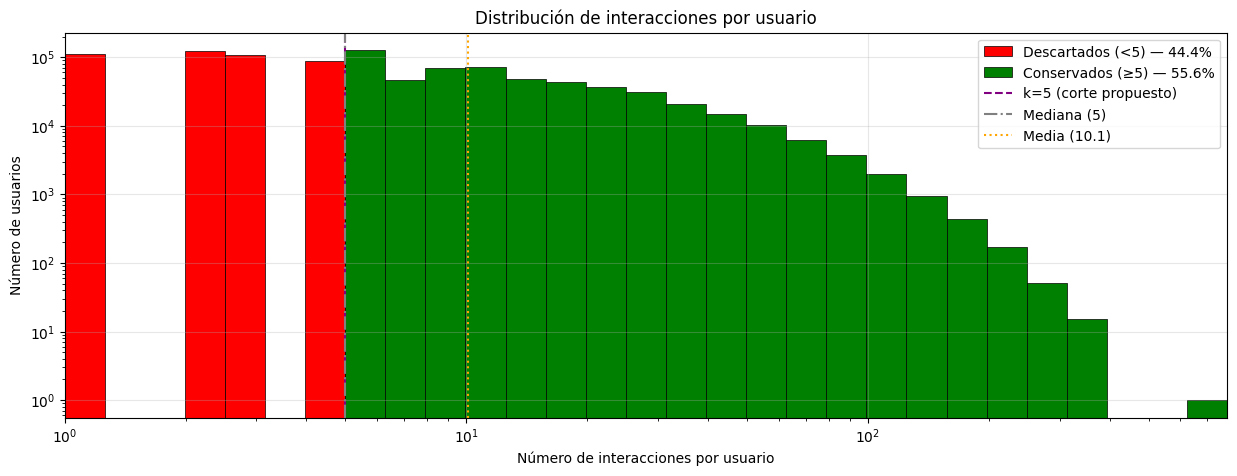

In [7]:
bins = np.logspace(0, np.log10(interaccion_user.max()), 30)
# Forzamos un borde en k=5 para que el corte quede limpio en el gráfico
bins = np.sort(np.unique(np.concatenate([bins, [5]])))

plt.figure(figsize=(15, 5))
plt.hist(usuarios_descartados, bins=bins, color='red', edgecolor='black',
         linewidth=0.5, label=f'Descartados (<5) — {len(usuarios_descartados)/len(interaccion_user)*100:.1f}%')
plt.hist(usuarios_conservados, bins=bins, color='green', edgecolor='black',
         linewidth=0.5, label=f'Conservados (≥5) — {len(usuarios_conservados)/len(interaccion_user)*100:.1f}%')
plt.xscale('log')
plt.yscale('log')
plt.xlim(1, interaccion_user.max())

plt.axvline(5, color='purple', linestyle='--', label='k=5 (corte propuesto)')
plt.axvline(interaccion_user.median(), color='gray', linestyle='-.',
            label=f'Mediana ({interaccion_user.median():.0f})')
plt.axvline(interaccion_user.mean(), color='orange', linestyle=':',
            label=f'Media ({interaccion_user.mean():.1f})')

plt.xlabel("Número de interacciones por usuario")
plt.ylabel("Número de usuarios")
plt.title("Distribución de interacciones por usuario")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

El histograma confirma visualmente la naturaleza **power-law** de la distribución (recta decreciente en escala log-log) y la decisión de corte: las barras rojas representan a los usuarios que descartamos, todos ellos en la «joroba» de baja actividad.

## 4. Distribución de interacciones por canción

Replicamos el análisis ahora desde la perspectiva de las canciones. Esto justificará el `k_item` del filtrado iterativo.

In [8]:
interaccion_track = df_history["track_id"].value_counts()
print(interaccion_track.describe(), "\n")
print(interaccion_track.quantile([0.9, 0.95, 0.99]))

count    30459.000000
mean       318.831905
std       1105.034895
min          1.000000
25%         13.000000
50%         57.000000
75%        255.000000
max      80656.000000
Name: count, dtype: float64 

0.90     738.00
0.95    1378.10
0.99    3835.94
Name: count, dtype: float64


**Lecturas:**
- La distribución de canciones está **muchísimo más sesgada** que la de usuarios: ratio media/mediana ≈ 5.6 (frente a ≈ 2 en usuarios).
- La cola es brutal: hay canciones con **hasta 80 656 escuchas**, casi tres órdenes de magnitud por encima de la mediana (57).
- Es la típica **«long tail»** del consumo musical: unos pocos hits acumulan la mayor parte de la atención, mientras que la mayoría del catálogo recibe muy poca.

In [9]:
for k in [2, 5, 10, 13, 57, 255]:
    pct = (interaccion_track < k).mean() * 100
    print(f"% Tracks con < {k} interacciones: {pct:.1f}%")
print(f"La canción con más interacciones tiene {max(interaccion_track)}")

k = 10
tracks_descartadas = interaccion_track[interaccion_track < k]
tracks_conservadas = interaccion_track[interaccion_track >= k]

% Tracks con < 2 interacciones: 3.3%
% Tracks con < 5 interacciones: 11.2%
% Tracks con < 10 interacciones: 20.3%
% Tracks con < 13 interacciones: 24.3%
% Tracks con < 57 interacciones: 50.0%
% Tracks con < 255 interacciones: 74.9%
La canción con más interacciones tiene 80656


**Justificación del corte `k_item = 10`:**

A diferencia de los usuarios, las canciones cubren un rango mucho más amplio. Un corte equivalente al de usuarios (en la mediana) sería demasiado agresivo: descartaríamos el 50 % de los tracks, eliminando canciones con 20–50 escuchas que son perfectamente válidas, solo menos populares.

Elegimos **`k_item = 10`** porque:
1. Garantiza al menos 10 evidencias por track, suficiente para aprender un embedding mínimamente fiable.
2. Conserva ~75 % del catálogo, manteniendo la diversidad musical del dataset.
3. Descarta tracks demasiado raros (con 1–5 escuchas en todo el dataset) que aportarían más ruido que señal a los modelos.

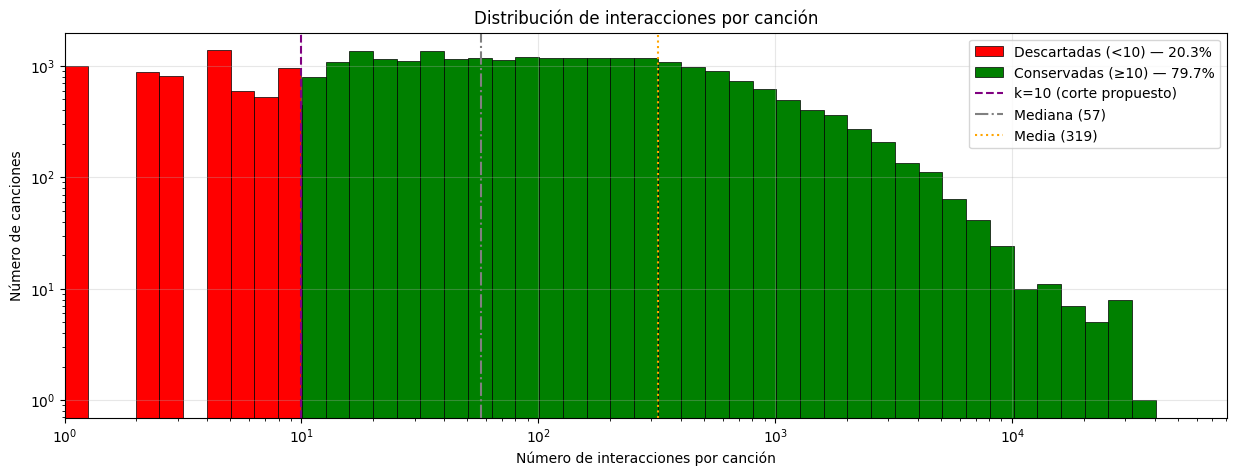

In [10]:
bins_track = np.logspace(0, np.log10(interaccion_track.max()), 50)
# Forzamos un borde en k=10 para que el corte quede limpio
bins_track = np.sort(np.unique(np.concatenate([bins_track, [10]])))

plt.figure(figsize=(15, 5))
plt.hist(tracks_descartadas, bins=bins_track, color='red', edgecolor='black',
         linewidth=0.5, label=f'Descartadas (<10) — {len(tracks_descartadas)/len(interaccion_track)*100:.1f}%')
plt.hist(tracks_conservadas, bins=bins_track, color='green', edgecolor='black',
         linewidth=0.5, label=f'Conservadas (≥10) — {len(tracks_conservadas)/len(interaccion_track)*100:.1f}%')
plt.xscale('log')
plt.yscale('log')
plt.xlim(1, interaccion_track.max())

plt.axvline(10, color='purple', linestyle='--', label='k=10 (corte propuesto)')
plt.axvline(interaccion_track.median(), color='gray', linestyle='-.',
            label=f'Mediana ({interaccion_track.median():.0f})')
plt.axvline(interaccion_track.mean(), color='orange', linestyle=':',
            label=f'Media ({interaccion_track.mean():.0f})')

plt.xlabel("Número de interacciones por canción")
plt.ylabel("Número de canciones")
plt.title("Distribución de interacciones por canción")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 5. Distribución de los playcounts

Ahora analizamos la **magnitud** de cada interacción: cuántas veces se escuchó realmente. Este análisis es clave para decidir cómo transformar `playcount` en un «rating» utilizable por los modelos.

In [11]:
playcount = df_history["playcount"]
print(playcount.describe(), "\n")
print(playcount.quantile([0.9, 0.95, 0.99]))

count    9.711301e+06
mean     2.630946e+00
std      5.706324e+00
min      1.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      2.000000e+00
max      2.948000e+03
Name: playcount, dtype: float64 

0.90     5.0
0.95     8.0
0.99    21.0
Name: playcount, dtype: float64


**Lecturas:**
- **Distribución brutalmente sesgada**: mediana = 1, percentil 75 = 2, percentil 99 = 21, máximo = 2 948. Los percentiles bajos están aplastados contra el valor 1.
- **Ratio media / mediana = 2.63**, otra firma de cola larga.
- Confirmación adicional: el dtype `uint16` permite hasta 65 535, y el máximo observado es 2 948, así que **no hay truncamiento de datos**.

Si usásemos `playcount` directamente como rating, los outliers extremos (2 948 frente a 1) dominarían la pérdida MSE del modelo: predecir bien la mayoría de las interacciones (que valen 1 o 2) sería irrelevante comparado con acertar la cola. Por eso es **obligatorio transformar la variable** antes de modelar.

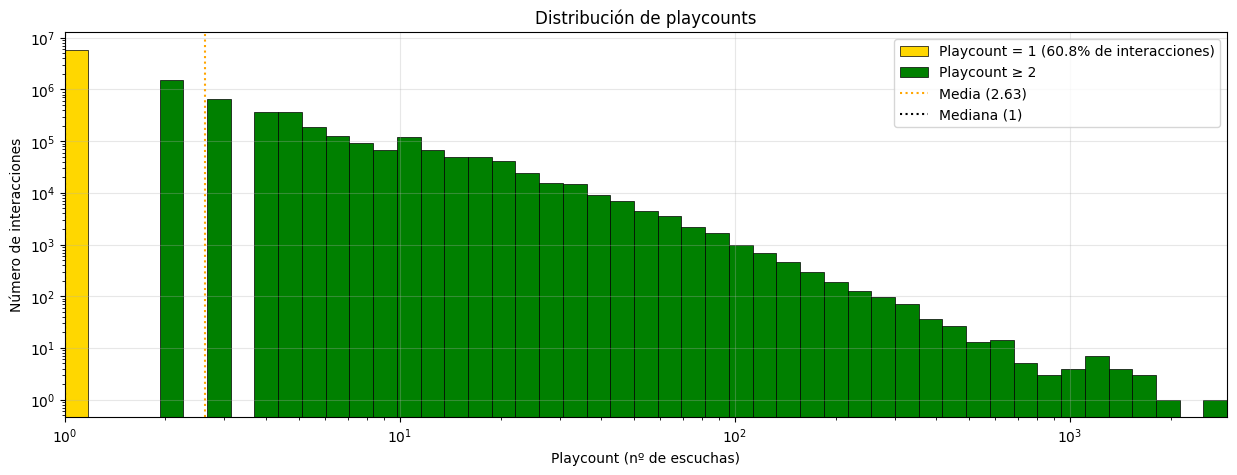

In [12]:
bins_pc = np.logspace(0, np.log10(playcount.max()), 50)
pct_uno = (playcount == 1).mean() * 100

plt.figure(figsize=(15, 5))
plt.hist(playcount[playcount <= 1], bins=bins_pc, color='gold', edgecolor='black',
         linewidth=0.5, label=f'Playcount = 1 ({pct_uno:.1f}% de interacciones)')
plt.hist(playcount[playcount > 1], bins=bins_pc, color='green', edgecolor='black',
         linewidth=0.5, label='Playcount ≥ 2')
plt.xscale('log')
plt.yscale('log')
plt.xlim(1, playcount.max())

plt.axvline(playcount.mean(), color='orange', linestyle=':', label=f'Media ({playcount.mean():.2f})')
plt.axvline(playcount.median(), color='black', linestyle=':', label=f'Mediana ({playcount.median():.0f})')

plt.xlabel("Playcount (nº de escuchas)")
plt.ylabel("Número de interacciones")
plt.title("Distribución de playcounts")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

**Observaciones clave del histograma:**
- La barra dorada (playcount = 1) representa el **60.8 %** de todas las interacciones. La mayoría aplastante del dataset son **«escuchas únicas»** que reflejan exploración casual más que preferencia confirmada.
- La cola se extiende hasta playcount ≈ 3 000, abarcando 3 órdenes de magnitud. Esta amplitud es inviable de alimentar directamente al modelo.

**Plan de transformación:** aplicaremos `log1p` para comprimir el rango, luego un **clipping al percentil 99** para descartar la influencia desproporcionada de los outliers extremos, y finalmente un escalado min-max al rango **[1, 5]** que es el habitual de rating explícito (coherente con el notebook de NCF de clase y con la literatura clásica).

## 6. Calibración del rating sintético

Antes de aplicar la transformación definitiva queremos **comprobar el significado intuitivo de cada nivel** de la escala 1–5: ¿a cuántas escuchas equivale cada estrella? Esto nos permite verificar que la escala resultante es interpretable.

In [13]:
log_pc_99 = np.log1p(playcount).clip(upper=np.log1p(playcount).quantile(0.99))
log_min_99 = log_pc_99.min()
log_max_99 = log_pc_99.max()

print("Equivalencia rating (escala 1-5) ↔ playcount con clipping p99:")
for r in np.arange(1, 5.1, 0.5):
    log_pc_equiv = log_min_99 + (r - 1) * (log_max_99 - log_min_99) / 4
    pc = np.exp(log_pc_equiv) - 1
    print(f"  Rating {r:.1f} -> playcount ≈ {pc:.1f}")

Equivalencia rating (escala 1-5) ↔ playcount con clipping p99:
  Rating 1.0 -> playcount ≈ 1.0
  Rating 1.5 -> playcount ≈ 1.7
  Rating 2.0 -> playcount ≈ 2.6
  Rating 2.5 -> playcount ≈ 3.9
  Rating 3.0 -> playcount ≈ 5.6
  Rating 3.5 -> playcount ≈ 8.0
  Rating 4.0 -> playcount ≈ 11.1
  Rating 4.5 -> playcount ≈ 15.3
  Rating 5.0 -> playcount ≈ 21.0


**Interpretación de la escala:**
- **Rating ≈ 1** → 1 escucha (interacción mínima, casi exploratoria).
- **Rating ≈ 3** → ~4 escuchas (interés moderado: ha vuelto varias veces).
- **Rating = 5** → 21 escuchas o más (afecto claro por la canción; representa el top 1 % del dataset).

Esta correspondencia es coherente con una interpretación intuitiva de la escala estilo Netflix/MovieLens (poco / moderado / mucho).

---
## 7. Decisiones finales y aplicación del filtrado

**Resumen de las decisiones del EDA:**
1. **k-core**: `k_user = 5`, `k_item = 10` (aplicado iterativamente hasta convergencia).
2. **Rating sintético**: `np.log1p(playcount)` → clipping al percentil 99 → escalado min-max al rango **[1, 5]** continuo.
3. **Split**: estratificado por usuario 80 / 20.

### 7.1. Filtrado iterativo (k-core)

El k-core debe aplicarse **iterativamente**: al filtrar usuarios con pocas interacciones, algunos tracks pueden quedar por debajo del umbral; y al filtrar esos tracks, algunos usuarios pueden quedar también por debajo. Iteramos hasta que el tamaño del DataFrame deje de cambiar (convergencia).

In [14]:
min_user = 5
min_track = 10

df_filtrado = df_history.copy()
original = len(df_filtrado)
print(f"Tamaño original: {original}")

while True:
    start_len = len(df_filtrado)

    track_counts = df_filtrado['track_id'].value_counts()
    valid_tracks = track_counts[track_counts >= min_track].index
    df_filtrado = df_filtrado[df_filtrado['track_id'].isin(valid_tracks)]

    user_counts = df_filtrado['user_id'].value_counts()
    valid_users = user_counts[user_counts >= min_user].index
    df_filtrado = df_filtrado[df_filtrado['user_id'].isin(valid_users)]

    end_len = len(df_filtrado)

    if start_len == end_len:
        break

print(f"Tamaño post-filtrado iterativo: {len(df_filtrado)}")
print(f"Se ha hecho una reduccion de {(1 - (len(df_filtrado) / original)) * 100:.3f}%")

Tamaño original: 9711301
Tamaño post-filtrado iterativo: 8650751
Se ha hecho una reduccion de 10.921%


**Conservamos el 89 %** del dataset original, descartando ~1 M de interacciones que correspondían a usuarios y/o canciones de actividad muy baja. Es un compromiso razonable: ganamos calidad estadística sin perder representatividad.

### 7.2. Mapeo de IDs a índices enteros consecutivos

Tras el filtrado, los IDs originales (strings) ya no son consecutivos. Los modelos basados en `nn.Embedding` de PyTorch requieren índices enteros en `[0, N-1]`, así que creamos columnas `user_n` y `track_n` con la nueva numeración. **Sin este paso, los embeddings darán `IndexError`.**

Mantenemos también una versión del DataFrame de metadatos (`df_music_mapped`) restringida a las canciones que sobreviven al filtrado, para análisis posteriores.

In [15]:
unique_tracks = df_filtrado['track_id'].unique()
track_map = {track: i for i, track in enumerate(unique_tracks)}

df_filtrado['track_n'] = df_filtrado['track_id'].map(track_map).astype('int32')

df_music_mapped = df_music[df_music['track_id'].isin(unique_tracks)].copy()
df_music_mapped['track_n'] = df_music_mapped['track_id'].map(track_map)

users_unicos = df_filtrado['user_id'].unique()
user_map = {user: i for i, user in enumerate(users_unicos)}

df_filtrado['user_n'] = df_filtrado['user_id'].map(user_map).astype(np.int32)

### 7.3. Creación del rating sintético

Aplicamos la transformación que validamos en la sección 6: `log1p` + clipping al percentil 99 + escalado min-max a [1, 5]. El rating queda como **valor continuo** (no se redondea a estrellas discretas) para preservar la información de la transformación; los modelos de regresión trabajarán mejor con un target continuo.

In [16]:
log_pc = np.log1p(df_filtrado['playcount'])
log_pc_clipped = log_pc.clip(upper=log_pc.quantile(0.99))
log_min = log_pc_clipped.min()
log_max = log_pc_clipped.max()

df_filtrado['rating'] = (1 + 4 * (log_pc_clipped - log_min) / (log_max - log_min)).astype(np.float32)

columnas_verificacion = ['user_id', 'user_n', 'track_id', 'track_n', 'playcount', 'rating']
display(df_filtrado[columnas_verificacion].head())
print("\nDistribución del rating final:")
print(df_filtrado['rating'].describe())

,user_id,user_n,track_id,track_n,playcount,rating
0,b80344d063b5ccb3212f76538f3d9e43d87dca9e,0,TRIRLYL128F42539D1,0,1,1.0
1,b80344d063b5ccb3212f76538f3d9e43d87dca9e,0,TRFUPBA128F934F7E1,1,1,1.0
2,b80344d063b5ccb3212f76538f3d9e43d87dca9e,0,TRLQPQJ128F42AA94F,2,1,1.0
3,b80344d063b5ccb3212f76538f3d9e43d87dca9e,0,TRTUCUY128F92E1D24,3,1,1.0
4,b80344d063b5ccb3212f76538f3d9e43d87dca9e,0,TRHDDQG12903CB53EE,4,1,1.0



Distribución del rating final:
count    8.650751e+06
mean     1.569806e+00
std      9.079416e-01
min      1.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      1.689750e+00
max      5.000000e+00
Name: rating, dtype: float64


### 7.4. Split estratificado por usuario (80 / 20)

Un split aleatorio puro sobre las 8.6 M de interacciones podría dejar a algunos usuarios completamente fuera de train (cold-start) o de test, lo que impediría evaluar el sistema sobre ellos. Para evitarlo, **dentro de cada usuario** asignamos el 80 % de sus interacciones a train y el 20 % a test.

Implementación en 3 pasos:
1. Asignar un número aleatorio a cada fila.
2. Convertirlo en un **percentil dentro del usuario** mediante `groupby('user_id').rank(pct=True)`. Este valor estará uniformemente distribuido en [0, 1] dentro de cada grupo.
3. Cortar al 80 %.

In [17]:
df_filtrado['random'] = np.random.rand(len(df_filtrado))
df_filtrado['random_user'] = df_filtrado.groupby('user_id', observed=True)['random'].rank(pct=True)

train_df = df_filtrado[df_filtrado['random_user'] <= 0.8].copy()
test_df = df_filtrado[df_filtrado['random_user'] > 0.8].copy()

# Limpieza: las columnas auxiliares no se necesitan en los splits finales
df_filtrado = df_filtrado.drop(columns=['random', 'random_user'])
train_df = train_df.drop(columns=['random', 'random_user'])
test_df = test_df.drop(columns=['random', 'random_user'])

In [18]:
print(f"Total: {len(df_filtrado)}")
print(f"Train: {len(train_df)} ({len(train_df) / len(df_filtrado) * 100:.1f}%)")
print(f"Test: {len(test_df)} ({len(test_df) / len(df_filtrado) * 100:.1f}%)")

n_users_total = df_filtrado['user_id'].nunique()
n_users_train = train_df['user_id'].nunique()
n_users_test = test_df['user_id'].nunique()
print(f"Usuarios en total: {n_users_total}")
print(f"Usuarios en train: {n_users_train}")
print(f"Usuarios en test: {n_users_test}")

Total: 8650751
Train: 6710683 (77.6%)
Test: 1940068 (22.4%)
Usuarios en total: 533689
Usuarios en train: 533689
Usuarios en test: 533689


**Verificación correcta:**
- Split real ≈ 77.6 / 22.4 (ligera desviación respecto al 80/20 esperado porque cada usuario tiene un número discreto de interacciones, que no siempre se divide exactamente).
- **Todos los 533 689 usuarios** aparecen tanto en train como en test. Cero cold-start. ✅

## 8. Guardado de los datos procesados

Guardamos los tres DataFrames (`df_filtrado`, `train_df`, `test_df`) en formato **parquet**, que es mucho más rápido de cargar que CSV y conserva los dtypes (`int32`, `float32`...). Los modelos de los demás notebooks leerán estos ficheros sin tener que re-ejecutar todo el EDA.

Guardamos también los diccionarios de mapeo `user_id ↔ user_n` y `track_id ↔ track_n` por si necesitamos volver a los IDs originales (por ejemplo, para inspeccionar recomendaciones cualitativamente con los metadatos).

In [19]:
output_path = '../data/processed/'
os.makedirs(output_path, exist_ok=True)

# DataFrames principales — guardamos en CSV (sin la columna user_id/track_id 'category' problemática)
df_filtrado_save = df_filtrado.copy()
df_filtrado_save['user_id'] = df_filtrado_save['user_id'].astype(str)
df_filtrado_save['track_id'] = df_filtrado_save['track_id'].astype(str)
df_filtrado_save.to_csv(output_path + 'df_filtrado.csv', index=False)

train_save = train_df.copy()
train_save['user_id'] = train_save['user_id'].astype(str)
train_save['track_id'] = train_save['track_id'].astype(str)
train_save.to_csv(output_path + 'train.csv', index=False)

test_save = test_df.copy()
test_save['user_id'] = test_save['user_id'].astype(str)
test_save['track_id'] = test_save['track_id'].astype(str)
test_save.to_csv(output_path + 'test.csv', index=False)

# Mapeos como pickle (los diccionarios no son tabulares, no se guardan en CSV)
with open(output_path + 'user_map.pkl', 'wb') as f:
    pickle.dump(user_map, f)
with open(output_path + 'track_map.pkl', 'wb') as f:
    pickle.dump(track_map, f)

# Metadatos
df_music_mapped.to_csv(output_path + 'music_info_filtered.csv', index=False)

print("Datos guardados en", output_path)
print(f"  - df_filtrado.csv ({len(df_filtrado):,} filas)")
print(f"  - train.csv ({len(train_df):,} filas)")
print(f"  - test.csv ({len(test_df):,} filas)")
print(f"  - user_map.pkl ({len(user_map):,} usuarios)")
print(f"  - track_map.pkl ({len(track_map):,} canciones)")
print(f"  - music_info_filtered.csv ({len(df_music_mapped):,} canciones con metadatos)")

Datos guardados en ../data/processed/
  - df_filtrado.csv (8,650,751 filas)
  - train.csv (6,710,683 filas)
  - test.csv (1,940,068 filas)
  - user_map.pkl (533,689 usuarios)
  - track_map.pkl (23,629 canciones)
  - music_info_filtered.csv (23,629 canciones con metadatos)


---
## 9. Resumen del EDA

Hemos partido del historial de escuchas crudo (962 037 usuarios × 30 459 canciones, 9.7 M interacciones, densidad 0.033 %) y, tras un análisis cuidadoso de las tres distribuciones clave (interacciones por usuario, por canción, y magnitud de los playcounts), hemos llegado a un dataset listo para modelado:

| Aspecto | Antes | Después |
|---|---|---|
| Usuarios | 962 037 | 533 689 |
| Canciones | 30 459 | ~25 000 (aprox., post k-core) |
| Interacciones | 9 711 301 | 8 650 751 (89 % conservado) |
| Target | playcount (rango 1–2 948) | rating continuo [1, 5] |
| Split | inexistente | 80/20 estratificado por usuario |

**Para los notebooks siguientes** (baseline, KNN, PMF, GMF, MLP) bastará con cargar `train.parquet` y `test.parquet`, usando las columnas `user_n`, `track_n` y `rating`.